In [1]:
# 1.1 Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.2 Modeling & NLP
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# NLP: sentiment example (VADER)
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# If nltk data not downloaded yet:
# nltk.download('vader_lexicon')

# Supplemental
import os
import json

In [2]:
# 2.3 Build a synthetic dataset for the whole USA (example)
np.random.seed(42)

# Example list of states
states = ['CA', 'TX', 'NY', 'FL', 'IL', 'PA', 'OH', 'GA', 'NC', 'MI']
n_records = 2000

df = pd.DataFrame({
    'team_id': np.arange(1, n_records+1),
    'team_name': [f'Team_{i}' for i in range(1, n_records+1)],
    'state': np.random.choice(states, size=n_records, p=None),
    'year': np.random.choice([2023, 2024], size=n_records, p=[0.6, 0.4]),
    'num_subscriptions': np.random.poisson(lam=500, size=n_records),
    'price_per_subscription': np.round(np.random.uniform(5, 25, size=n_records), 2),
    # Markup or cost factors
    'cost_per_subscription': np.round(np.random.uniform(2, 10, size=n_records), 2),
})

# Calculate gross_sales, cost, profit
df['gross_sales'] = df['num_subscriptions'] * df['price_per_subscription']
df['total_cost'] = df['num_subscriptions'] * df['cost_per_subscription']
df['profit'] = df['gross_sales'] - df['total_cost']
df['profit_margin'] = df['profit'] / df['gross_sales']

# Add simple text field
sample_descriptions = [
    "Aggressive lineup with weekly analysis and premium picks.",
    "Value-focused picks, aimed at casual players.",
    "Expert tips, deep stats, and community chat included.",
    "Newcomer friendly; easy setup and low cost.",
    "High-variance strategy with special bonuses.",
]
df['team_description'] = np.random.choice(sample_descriptions, size=n_records)

# Optionally add customer comments / feedback for NLP
sample_comments = [
    "Loved the stats, very helpful!",
    "Too expensive for casual use.",
    "Great value, multiple wins!",
    "Not enough detailed analysis.",
    "Community is fun but needs more tips."
]
df['customer_comment'] = np.random.choice(sample_comments, size=n_records)

# Quick look
df.head()

,team_id,team_name,state,year,num_subscriptions,price_per_subscription,cost_per_subscription,gross_sales,total_cost,profit,profit_margin,team_description,customer_comment
0,1,Team_1,OH,2023,501,16.02,4.96,8026.02,2484.96,5541.06,0.690387,High-variance strategy with special bonuses.,"Loved the stats, very helpful!"
1,2,Team_2,FL,2023,532,19.17,2.57,10198.44,1367.24,8831.20,0.865936,Aggressive lineup with weekly analysis and pre...,Not enough detailed analysis.
2,3,Team_3,GA,2024,501,7.29,9.15,3652.29,4584.15,-931.86,-0.255144,"Expert tips, deep stats, and community chat in...",Too expensive for casual use.
3,4,Team_4,IL,2023,501,11.11,9.11,5566.11,4564.11,1002.00,0.180018,High-variance strategy with special bonuses.,Too expensive for casual use.
4,5,Team_5,OH,2023,494,20.63,8.84,10191.22,4366.96,5824.26,0.571498,Aggressive lineup with weekly analysis and pre...,"Great value, multiple wins!"


In [3]:
df.to_csv('fantasy_teams_sales_demo.csv', index=False)

In [4]:
# 3.1 Load dataset (synthetic or your real CSV)
df = pd.read_csv('fantasy_teams_sales_demo.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   team_id                 2000 non-null   int64  
 1   team_name               2000 non-null   object 
 2   state                   2000 non-null   object 
 3   year                    2000 non-null   int64  
 4   num_subscriptions       2000 non-null   int64  
 5   price_per_subscription  2000 non-null   float64
 6   cost_per_subscription   2000 non-null   float64
 7   gross_sales             2000 non-null   float64
 8   total_cost              2000 non-null   float64
 9   profit                  2000 non-null   float64
 10  profit_margin           2000 non-null   float64
 11  team_description        2000 non-null   object 
 12  customer_comment        2000 non-null   object 
dtypes: float64(6), int64(3), object(4)
memory usage: 203.3+ KB


In [5]:
# Drop duplicates if any
df.drop_duplicates(subset=['team_id', 'year'], inplace=True)

# Replace or drop missing values
df.fillna({
    'price_per_subscription': df['price_per_subscription'].median(),
    'cost_per_subscription': df['cost_per_subscription'].median(),
    'team_description': '',
    'customer_comment': ''
}, inplace=True)

# If profit or margin missing, recalc
df['gross_sales'] = df['num_subscriptions'] * df['price_per_subscription']
df['total_cost'] = df['num_subscriptions'] * df['cost_per_subscription']
df['profit'] = df['gross_sales'] - df['total_cost']
df['profit_margin'] = df['profit'] / df['gross_sales']

In [6]:
# Example placeholder ACS data
demo = pd.DataFrame({
    'state': states,
    'median_income': [80000, 60000, 75000, 55000, 65000, 70000, 58000, 50000, 52000, 54000],
    'population': [39_000_000, 30_000_000, 19_000_000, 22_000_000, 12_000_000, 13_000_000, 11_000_000, 10_000_000, 10_500_000, 10_000_000]
})

df = df.merge(demo, on='state', how='left')

In [7]:
# Initialize
sid = SentimentIntensityAnalyzer()

def sentiment_score(text):
    scores = sid.polarity_scores(str(text))
    return scores['compound']

# Compute
df['desc_sentiment'] = df['team_description'].apply(sentiment_score)
df['comment_sentiment'] = df['customer_comment'].apply(sentiment_score)

df[['team_description', 'desc_sentiment']].head()

,team_description,desc_sentiment
0,High-variance strategy with special bonuses.,0.7430
1,Aggressive lineup with weekly analysis and pre...,-0.1531
2,"Expert tips, deep stats, and community chat in...",0.0000
3,High-variance strategy with special bonuses.,0.7430
4,Aggressive lineup with weekly analysis and pre...,-0.1531


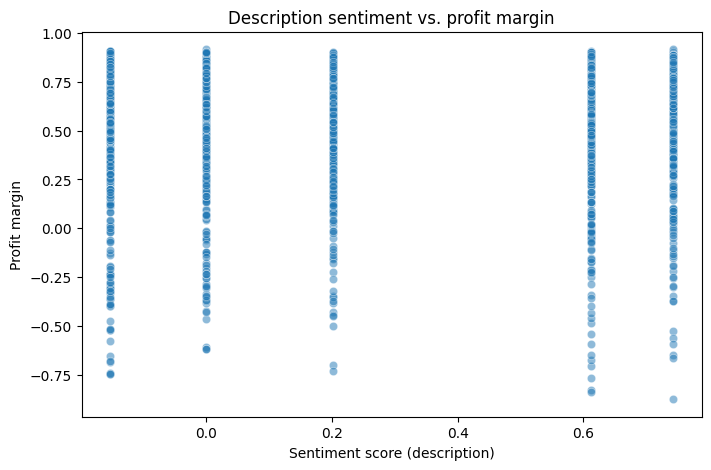

,state,avg_sentiment,avg_profit_margin,total_profit
0,CA,0.265987,0.521005,1005567.04
1,FL,0.270561,0.517750,819171.31
2,GA,0.261665,0.526514,920741.15
3,IL,0.281445,0.535624,964895.67
4,MI,0.325803,0.537098,952048.97
5,NC,0.253415,0.520317,907987.81
6,NY,0.254002,0.518185,915567.00
7,OH,0.304805,0.514829,871928.05
8,PA,0.299416,0.478236,817480.63
9,TX,0.276607,0.483822,846026.39


In [8]:
# Visual: sentiment vs profit margin
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='desc_sentiment', y='profit_margin', alpha=0.5)
plt.title('Description sentiment vs. profit margin')
plt.xlabel('Sentiment score (description)')
plt.ylabel('Profit margin')
plt.show()

# Average sentiment by state, aligned with profits
state_sent = df.groupby('state').agg(
    avg_sentiment=('desc_sentiment', 'mean'),
    avg_profit_margin=('profit_margin', 'mean'),
    total_profit=('profit', 'sum')
).reset_index()

state_sent

In [9]:
# Target: profit or profit_margin
target = 'profit'  # or 'profit_margin'

# Candidate features
features = [
    'num_subscriptions',
    'price_per_subscription',
    'cost_per_subscription',
    # demographics
    'median_income',
    'population',
    # NLP features
    'desc_sentiment',
    'comment_sentiment',
    # categorical
    'state',
    'year'
]

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Categorical columns
categorical_cols = ['state', 'year']
numeric_cols = [c for c in features if c not in categorical_cols]

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Decision Tree regressor
tree = DecisionTreeRegressor(
    max_depth=5,       # example; tune as needed
    min_samples_leaf=10,
    random_state=42
)

pipe = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', tree)
])

# Fit
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [11]:
# Predictions
y_pred = pipe.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}, R^2: {r2:.3f}')

MSE: 340344.37, R^2: 0.962


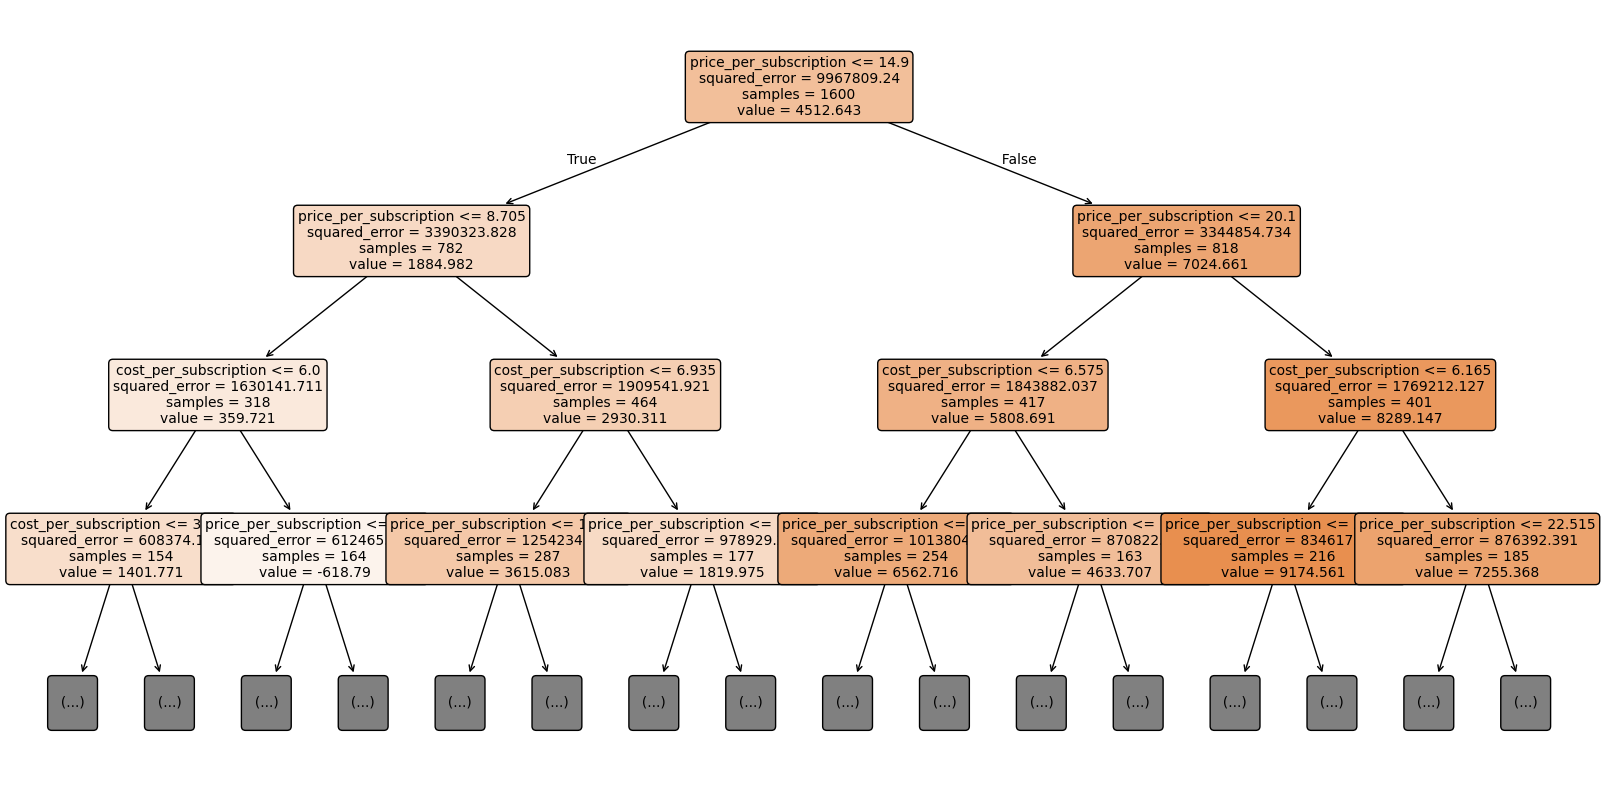

In [12]:
# Extract trained tree
model = pipe.named_steps['model']
feature_names = numeric_cols + list(pipe.named_steps['pre'].transformers_[1][1].get_feature_names_out(categorical_cols))

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,  # limit depth for readability
    fontsize=10
)
plt.show()

In [13]:
# Top teams by total profit
top_profit = df.sort_values('profit', ascending=False).head(10)
top_profit[['team_name', 'state', 'profit', 'profit_margin', 'num_subscriptions']]

# Top states by total profit
top_states = df.groupby('state').agg(
    total_profit=('profit', 'sum'),
    avg_profit_margin=('profit_margin', 'mean'),
    total_sales=('gross_sales', 'sum')
).sort_values('total_profit', ascending=False).reset_index()

top_states.head(10)

,state,total_profit,avg_profit_margin,total_sales
0,CA,1005567.04,0.521005,1672055.11
1,IL,964895.67,0.535624,1591852.11
2,MI,952048.97,0.537098,1539961.59
3,GA,920741.15,0.526514,1535493.16
4,NY,915567.00,0.518185,1529751.25
5,NC,907987.81,0.520317,1484841.09
6,OH,871928.05,0.514829,1443475.49
7,TX,846026.39,0.483822,1454505.40
8,FL,819171.31,0.517750,1351131.62
9,PA,817480.63,0.478236,1400341.68


In [14]:
# Which teams have the most positive descriptions?
top_desc_sent = df.sort_values('desc_sentiment', ascending=False).head(10)
top_desc_sent[['team_name', 'desc_sentiment', 'profit']]

# By positive comments
top_comment_sent = df.sort_values('comment_sentiment', ascending=False).head(10)
top_comment_sent[['team_name', 'comment_sentiment', 'profit']]

,team_name,comment_sentiment,profit
1559,Team_1560,0.8883,6205.64
296,Team_297,0.8883,-1132.06
551,Team_552,0.8883,-1833.79
1456,Team_1457,0.8883,6891.19
552,Team_553,0.8883,4975.00
1459,Team_1460,0.8883,3495.92
915,Team_916,0.8883,2893.84
304,Team_305,0.8883,792.18
1476,Team_1477,0.8883,4573.22
557,Team_558,0.8883,4929.64


In [15]:
# Filter for profit > median and sentiment > 0.2
median_profit = df['profit'].median()
top_combo = df[
    (df['profit'] > median_profit) &
    (df['desc_sentiment'] > 0.2)
].sort_values('profit', ascending=False).head(20)

top_combo[['team_name', 'profit', 'desc_sentiment', 'state']]

,team_name,profit,desc_sentiment,state
1696,Team_1697,12381.85,0.2023,NC
411,Team_412,11318.24,0.2023,NC
1861,Team_1862,11263.62,0.6124,OH
1891,Team_1892,11205.20,0.2023,PA
773,Team_774,11181.08,0.7430,GA
1383,Team_1384,10937.92,0.7430,NC
365,Team_366,10888.18,0.2023,CA
163,Team_164,10840.18,0.6124,FL
537,Team_538,10789.92,0.7430,MI
1773,Team_1774,10617.36,0.6124,TX


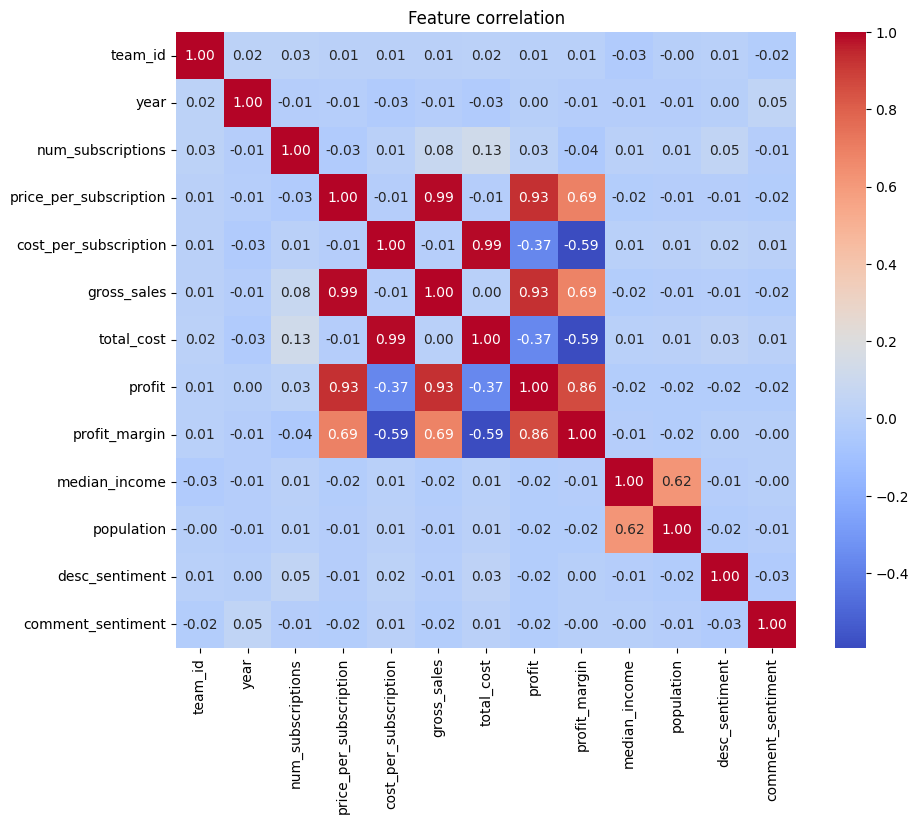

In [16]:
plt.figure(figsize=(10,8))
numeric_feats = df.select_dtypes(include=[np.number])
corr = numeric_feats.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature correlation')
plt.show()

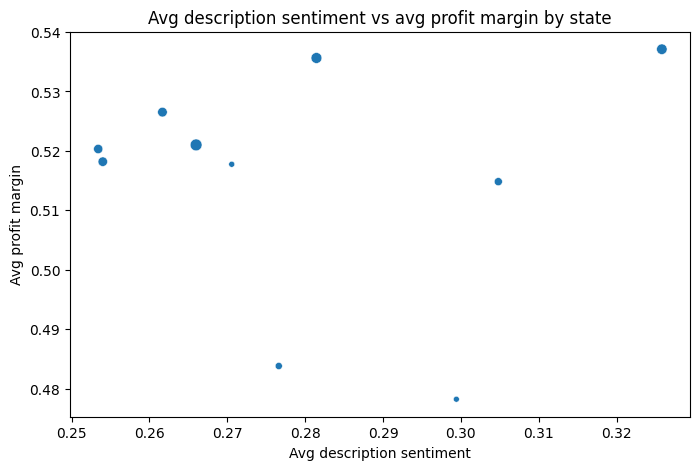

In [17]:
# For example, are higher median_income states generating higher profit margins?
plt.figure(figsize=(8,5))
sns.scatterplot(data=state_sent, x='avg_sentiment', y='avg_profit_margin', size='total_profit', legend=False)
plt.title('Avg description sentiment vs avg profit margin by state')
plt.xlabel('Avg description sentiment')
plt.ylabel('Avg profit margin')
plt.show()

In [18]:
# Profit growth or decline from year to year
yearly = df.groupby('year').agg(
    total_profit=('profit', 'sum'),
    avg_profit_margin=('profit_margin', 'mean')
).reset_index()

yearly

,year,total_profit,avg_profit_margin
0,2023,5344522.97,0.518017
1,2024,3676891.05,0.512508
